Total cells: 665


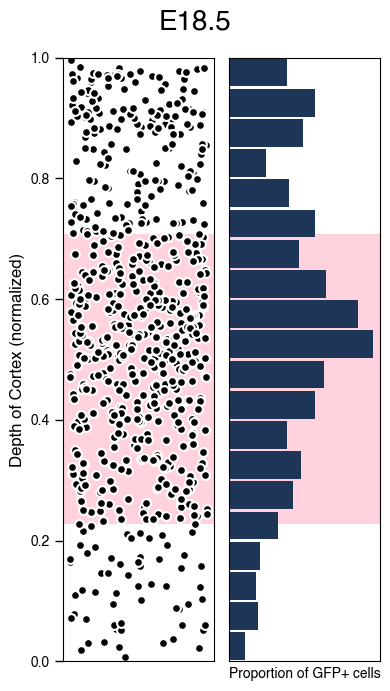

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['font.family'] = 'Helvetica'

# ── Load data ────────────────────────────────────────────────────────────────
E17homo = pd.read_csv('/Users/tazakkaadie/Documents/UALBERTA/NEURO 452/final sheets/cell migration 2 - E18 new homo.csv')
E17homo_cells = E17homo.iloc[:, 2].values

df = pd.read_csv("/Users/tazakkaadie/Documents/UALBERTA/NEURO 452/final sheets/cell migration 2 - E18 new homo.csv")
y_positions = df.iloc[:, 2].dropna().values

# ── Figure with 2 subplots side by side ──────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(4, 7))
fig.suptitle('E18.5', fontsize=20, fontweight='bold')

# ── Scatter plot (left) ───────────────────────────────────────────────────────
n2_cells = len(E17homo)
np.random.seed(42)
x1_positions = np.random.uniform(0, 0.3, n2_cells)

ax1.scatter(x1_positions, E17homo_cells,
            s=40,
            color='black',
            alpha=1,
            edgecolors='white',
            linewidth=1.5)

ax1.set_ylabel('Depth of Cortex (normalized)', fontsize=12)
ax1.set_ylim(0, 1)
ax1.set_xticks([])
ax1.tick_params(axis='y', direction='out', length=6, width=1)

#CTIP depth
band_ymin = 0.2271068213
band_ymax = 0.7084713843

ax1.axhspan(band_ymin, band_ymax, facecolor='#ff1f5b', alpha=0.2, zorder=0)

# ── Histogram (right) ─────────────────────────────────────────────────────────
bin_edges = np.arange(0, 1.05, 0.05)
bin_width = 0.05

counts, _ = np.histogram(y_positions, bins=bin_edges)
counts = counts / len(y_positions)  # normalize by total number of cells
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

ax2.barh(
    y      = bin_centers,
    width  = counts,
    height = bin_width * 0.92,
    color  = "#1d3557",
    zorder = 2,
)

ax2.set_ylim(0, 1)
ax2.set_xlim(left=0)
ax2.set_xlabel('Proportion of GFP+ cells', fontsize=10)
ax2.set_yticks([])
ax2.tick_params(axis="x", bottom=False, top=False, labelbottom=False, labeltop=False)
ax2.axhspan(band_ymin, band_ymax, facecolor='#ff1f5b', alpha=0.2, zorder=0)

for spine in ["top", "right", "left", "bottom"]:
    ax2.spines[spine].set_visible(True)

ax2.xaxis.set_major_locator(plt.MultipleLocator(0.1))

# ── Save & show ───────────────────────────────────────────────────────────────
print(f"Total cells: {len(y_positions)}")

plt.tight_layout()
plt.savefig('/Users/tazakkaadie/Downloads/combined_E18.5 homo.png', dpi=500, transparent=True)
plt.show()

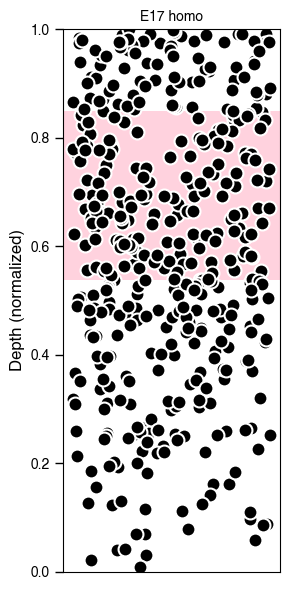

In [15]:
#scatterplot
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

E17homo = pd.read_csv('/Users/tazakkaadie/Documents/UALBERTA/NEURO 452/final sheets/cell migration 2 - comb E17 homo.csv')
E17homo_cells = E17homo.iloc[:, 2].values

fig, axs = plt.subplots(figsize=(3, 6))

n2_cells = len(E17homo)
np.random.seed(42)
x1_positions = np.random.uniform(0, 0.3, n2_cells)

axs.scatter(x1_positions, E17homo_cells,   # <-- fixed variable name
            s=100,
            color='black',
            alpha=1,
            edgecolors='white',
            linewidth=1.5)

axs.set_ylabel('Depth (normalized)', fontsize=12)   # <-- axs, not plt
axs.set_ylim(0, 1)
axs.set_title('E17 homo', fontsize=10, fontweight='bold')
axs.set_xticks([])
axs.tick_params(axis='y', direction='out', length=6, width=1)
axs.axhspan(0.5371046019, 0.8499280835, facecolor='#ff1f5b', alpha=0.2, zorder=0)

plt.savefig('/Users/tazakkaadie/Downloads/comb E17 homo.png', dpi=500, transparent=True)

plt.tight_layout()
plt.show()

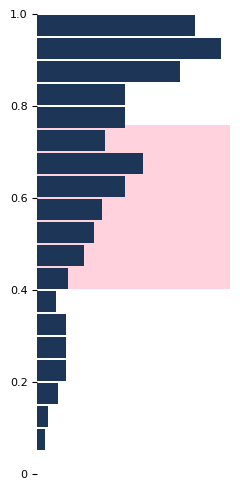

Saved to vertical_histogram.png


In [15]:
# vertical histogram

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd

# ── YOUR DATA ────────────────────────────────────────────────────────────────
# Replace this with your actual array of normalized y-positions (values 0–1)

df = pd.read_csv("/Users/tazakkaadie/Documents/UALBERTA/NEURO 452/final sheets/cell migration 2 - E17 Pten KO.csv")
y_positions = df.iloc[:, 2].dropna().values  # column C (index 2)

# Bin edges: 0.00, 0.05, 0.10, …, 1.00  (20 bins)
bin_edges = np.arange(0, 1.05, 0.05)
bin_width = 0.05

counts, _ = np.histogram(y_positions, bins=bin_edges)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

fig, ax = plt.subplots(figsize=(2.5, 5))


# ── Horizontal bars (one per bin) ────────────────────────────────────────────
ax.barh(
    y       = bin_centers,
    width   = counts,
    height  = bin_width * 0.92,   # slight gap between bars
    color   = "#1d3557",
    zorder  = 2,
)

# ── Axes formatting ───────────────────────────────────────────────────────────
ax.set_ylim(0, 1)
ax.set_xlim(left=0)

ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0", "0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=8)

ax.set_xlabel("")
ax.tick_params(axis="x", bottom=False, top=False, labelbottom=False, labeltop=False)

ax.axhspan(0.4019706962, 0.7589369159, facecolor='#ff1f5b', alpha=0.2, zorder=0)

# Remove spines for a clean look
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["top", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/tazakkaadie/Downloads/histo E17 Pten KO new.png', dpi=300, transparent=True)
plt.show()
print("Saved to vertical_histogram.png")

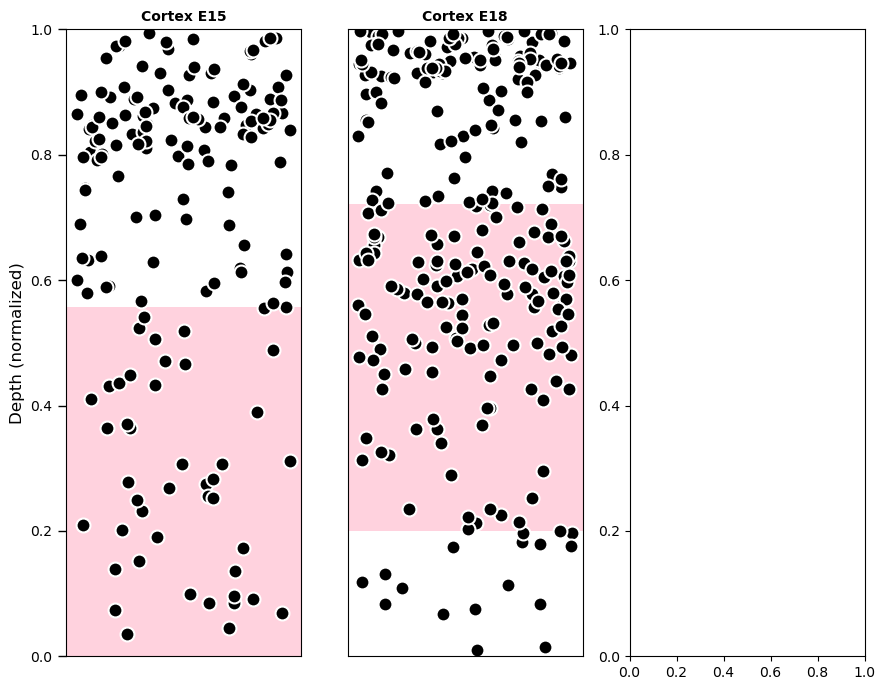

Visualized 327 E15 cells
Visualized 517 E18 cells
Value range: nan - nan


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

E15homo = pd.read_csv('/Users/tazakkaadie/Documents/NEURO 452 papers/excel sheets/E15 Gad2 homo (1).csv')
E18homo = pd.read_csv('/Users/tazakkaadie/Documents/NEURO 452 papers/excel sheets/E18 Gad2 homo2.csv')

cell_values = E15homo.iloc[:, 2].values #3rd column
E18_cells = E18homo.iloc[:, 2].values

# Number of cells
n_cells = len(cell_values)
n2_cells = len(E18_cells)

# Generate random x-positions for each cell
np.random.seed(42)  # For reproducibility - remove this for different random positions each time
x1_positions = np.random.uniform(0, 0.3, n_cells)
x2_positions = np.random.uniform(0, 0.3, n2_cells)

# Create the plot
fig, axs = plt.subplots(1, 3, figsize=(9, 7))

# Plot the cells
scatter = axs[0].scatter(x1_positions, cell_values, 
                    s=100,  # Size of points
                    color='black',
                    alpha=1,  # Transparency
                    edgecolors='white',  # Border around points
                    linewidth=1.5)


# Customize the plot
axs[0].set_ylabel('Depth (normalized)', fontsize=12)
axs[0].set_ylim(0, 1)  # Slightly extend y-axis for better visibility
axs[0].set_title('Cortex E15', fontsize=10, fontweight='bold')

# Remove x-axis ticks
axs[0].set_xticks([])

# Keep y-axis ticks but move them outside
axs[0].tick_params(axis='y', direction='out', length=6, width=1)

axs[0].axhspan(0, 0.557, facecolor='#ff1f5b', alpha=0.2, zorder=0)
# axs[0].axhspan(0.3, 0.65, facecolor='#009ade', alpha=0.2, zorder=0)
# axs[0].axhspan(0.65, 1, facecolor='#ffc61e', alpha=0.2, zorder=0)

# Plot the cells
scatter = axs[1].scatter(x2_positions, E18_cells, 
                    s=100,  # Size of points
                    color='black',
                    alpha=1,  # Transparency
                    edgecolors='white',  # Border around points
                    linewidth=1.5)


# Customize the plot
axs[1].set_ylim(0, 1)  # Slightly extend y-axis for better visibility
axs[1].set_title('Cortex E18', fontsize=10, fontweight='bold')

# Remove x-axis ticks
axs[1].set_xticks([])
axs[1].set_yticks([])

# Keep y-axis ticks but move them outside
axs[1].tick_params(axis='y', direction='out', length=6, width=1)
axs[1].axhspan(0.200, 0.722, facecolor='#ff1f5b', alpha=0.2, zorder=0)

plt.savefig('/Users/tazakkaadie/Downloads/GAD HOMO E15 & E18.png', 
            dpi=300,
            transparent=True)

plt.tight_layout()
plt.show()

print(f"Visualized {n_cells} E15 cells")
print(f"Visualized {n2_cells} E18 cells")
print(f"Value range: {cell_values.min():.2f} - {cell_values.max():.2f}")

In [ ]:
# Number of cells
n_cells = len(cell_values)
n2_cells = len(E18_cells)

#Counting cells in each region

count_0_to_03 = np.sum((cell_values >= 0) & (cell_values < 0.3))
count_03_to_07 = np.sum((cell_values >= 0.3) & (cell_values < 0.7))
count_07_to_10 = np.sum((cell_values >= 0.7) & (cell_values <= 1.0))

print(f"\nCounts by region:")
print(f"  0.0 - 0.3: {count_0_to_03}")
print(f"  0.3 - 0.7: {count_03_to_07}")
print(f"  0.7 - 1.0: {count_07_to_10}")
